# **How do geographic factors affect GDP per capita across and within countries?**

Economic Modelling and Data Science

Candidate number: 2610172   

Date: 09/05/2026

Presentation Link: https://youtu.be/2sUowWhxNoY
---


**ABSTRACT**

In this project, I investigate how geographic factors influence economic performance across and within different countries. Using World Bank data from 2010–2020, in addition to CEPII, for landlocked countries, I explore relationships between variables such as agricultural land use, natural resources, population density, and GDP per capita.

Through exploratory data analysis and fixed effects regression models, I examine how these factors relate to economic outcomes over time. The results suggest that geographic and structural characteristics are linked to economic performance, although the relationships vary across countries and models.

# **TABLE OF CONTENTS**

1. Introduction
2. Data Loading and Cleaning
3. Data Graphs
4. Regressions
5. Fixed effects model/regression
6. Additional Control Variables
7. Final Models
8. Comparing Results
9. Model Diagnostics
10. Limitations
11. Conclusion

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from linearmodels import PooledOLS, PanelOLS, RandomEffects
from statsmodels.api import add_constant
import statsmodels.api as sm


# **INTRODUCTION**

The purpose of this research question is to investigate how geographic factors affect economic performance across different countries. The idea is to see whether countries with particular geographic endowments, such as natural resources or agricultural land, create an economic edge over others.

For example, countries with large amounts of agricultural land can export crops to other countries, which in turn increases GDP. Similarly, countries with high natural resource reserves can not only export resources but also have less necessity for importing from other countries, which, ceteris paribus, increases GDP.

On the other hand, economic success requires an amalgamation of many different factors, such as the quality of human capital, corruption, or even military strength. Therefore, geography may have a limited effect on economic performance. The goal of this project is to measure the extent of this effect.

# **DATA LOADING AND CLEANING**

In [ ]:
agri_df = pd.read_csv("https://raw.githubusercontent.com/brysagay/Datascience_project/refs/heads/main/AgricultureLand.csv") # pd.read_csv used to read the raw files

In [ ]:
gdpC_df = pd.read_csv("https://raw.githubusercontent.com/brysagay/Datascience_project/refs/heads/main/GDP%20per%20Capita.csv")

In [ ]:
n_res = pd.read_csv("https://raw.githubusercontent.com/brysagay/Datascience_project/refs/heads/main/NaturalResources.csv")

In [ ]:
geo_df = pd.read_csv("https://raw.githubusercontent.com/brysagay/Datascience_project/refs/heads/main/geo_cepii.csv")


I retrieved my data from the World Bank and CEPII. I used the World Bank to get the GDP Per Capita, Natural Resource Rents (% of GDP) and Agricultural Land (% of total land area). For the landlocked status of countries, I used CEPII.

To then read the datasets, I uploaded them as CSVs on a GitHub server which can then be read using pandas.

In [ ]:
def cleanA(x): # This is a function to easily clean the world bank data since thats where i retrived most my datasets from (they have similar format)
  x = x.replace(["..", "", " ", "NA", "N/A"], np.nan) # This replaces all the NA formats python wouldn't recognise with np.nan - which makes dropping missing value easier later on
  x = x.dropna() # drops the missing values. I used it loosely since i already had a large amount of countries. So dropping some countries entirely wasn't an issue.
  x.columns = x.columns.str.replace(r" \[YR\d+\]", "", regex=True) # This applies a string replacement. The first space after r matches to any space in the string. \[,  matches with the opening bracket. YR matches with the YR part of the string. \d+ takes any digits, one or more. \] now matches with the closing bracket. The last argument, "", replaces whatever it matches with a text in to brakets in this case nothing. Regex just tells python to read it as a regular expression and replace other columns with the same pattern.
  x = x.drop(columns=["Series Name","Series Code"]) # drops columns I dont need
  x = x.melt(id_vars=["Country Name","Country Code"],var_name="Year",value_name="Agricultural Land") # this transforms the data from wide to long format, leaving the country name and Code the same as the "id_vars". Var_name creates a new column for the old variable Year in this case and a seperate column for the values previously under it which is named through value_name.
  return x # This just returns the new cleaned dataset - this applies to the other cleaning functions

In [ ]:
def cleanN(x):
  x = x.replace(["..", "", " ", "NA", "N/A"], np.nan)
  x = x.dropna()
  x.columns = x.columns.str.replace(r" \[YR\d+\]", "", regex=True)
  x = x.drop(columns=["Series Name","Series Code"])
  x = x.melt(id_vars=["Country Name","Country Code"],var_name="Year",value_name="Natural Resource")
  return x

In [ ]:
def cleanG(x):
  x = x.replace(["..", "", " ", "NA", "N/A"], np.nan)
  x = x.dropna()
  x.columns = x.columns.str.replace(r" \[YR\d+\]", "", regex=True)
  x = x.drop(columns=["Series Name","Series Code"])
  x = x.melt(id_vars=["Country Name","Country Code"],var_name="Year",value_name="GDP Per Capita")
  return x

In [ ]:
agri_df = cleanA(agri_df) # Applying the function previously created
n_res = cleanN(n_res)
gdpC_df = cleanG(gdpC_df)

In [ ]:
agri_df.head() # To see if the cleaning function worked

,Country Name,Country Code,Year,Agricultural Land
0,Africa Eastern and Southern,AFE,2010,43.302093
1,Africa Western and Central,AFW,2010,39.009539
2,Arab World,ARB,2010,36.466549
3,Caribbean small states,CSS,2010,3.575511
4,Central Europe and the Baltics,CEB,2010,47.052212


In [ ]:
n_res.head()

,Country Name,Country Code,Year,Natural Resource
0,Africa Eastern and Southern,AFE,2010,12.027292
1,Africa Western and Central,AFW,2010,14.228939
2,Arab World,ARB,2010,27.774052
3,Caribbean small states,CSS,2010,8.584970
4,Central Europe and the Baltics,CEB,2010,2.200292


In [ ]:
gdpC_df.head() # Note that I'd already retrieved this dataset for a different project question hence the range is from 1999.

,Country Name,Country Code,Year,GDP Per Capita
0,Albania,ALB,1999,1056.344812
1,Algeria,DZA,1999,1596.118222
2,Andorra,AND,1999,18875.288370
3,Angola,AGO,1999,392.725539
4,Antigua and Barbuda,ATG,1999,11342.334923


In [ ]:
econ_df = pd.merge(n_res,agri_df, on=["Year","Country Name","Country Code"]) # Merging all three datasets on Year, Country Name and Country Code
econ_df = pd.merge(econ_df,gdpC_df, on = ["Year","Country Name","Country Code"])

In [ ]:
econ_df

,Country Name,Country Code,Year,Natural Resource,Agricultural Land,GDP Per Capita
0,Albania,ALB,2010,1.528168,43.843066,4149.144699
1,Algeria,DZA,2010,25.538324,17.371334,4912.785855
2,Andorra,AND,2010,0.000000,42.063830,42746.830392
3,Angola,AGO,2010,38.162310,35.974974,4101.637156
4,Antigua and Barbuda,ATG,2010,0.000000,20.454545,15217.395079
...,...,...,...,...,...,...
2085,Vanuatu,VUT,2020,0.629508,15.340443,3042.987116
2086,Viet Nam,VNM,2020,1.810882,39.434768,3534.039535
2087,West Bank and Gaza,PSE,2020,0.000000,67.751429,3233.568638
2088,Zambia,ZMB,2020,16.222231,32.067959,951.644317


In [ ]:
geo_df.head(5) # Seeing how the CEPII dataset looks so i can see how to clean it.

,iso2,iso3,cnum,country,pays,area,dis_int,landlocked,continent,city_en,...,lang9_2,lang9_3,lang9_4,colonizer1,colonizer2,colonizer3,colonizer4,short_colonizer1,short_colonizer2,short_colonizer3
0,AW,ABW,533,Aruba,Aruba,193,5.225315,0,America,Oranjestad,...,.,.,.,NLD,.,.,.,.,.,.
1,AF,AFG,4,Afghanistan,Afghanistan,652225,303.761400,1,Asia,Kabul,...,Uzbek,.,.,.,.,.,.,GBR,.,.
2,AO,AGO,24,Angola,Angola,1246700,419.966600,0,Africa,Luanda,...,.,.,.,PRT,.,.,.,.,.,.
3,AI,AIA,660,Anguilla,Anguilla,102,3.798690,0,America,The Valley,...,.,.,.,GBR,.,.,.,.,.,.
4,AL,ALB,8,Albania,Albanie,28748,63.773110,0,Europe,Tirana,...,.,.,.,TUR,.,.,.,.,.,.


In [ ]:
geo_df = geo_df[["iso3","country","landlocked"]] # Keeping only the columns i need

In [ ]:
geo_df = geo_df.rename(columns={"iso3":"Country Code","country":"Country Name"}) # I rename all the columsn so I can merge later on to my previous dataset (econ_df)

In [ ]:
geo_df.head(5) # seeing if the cleaning worked

,Country Code,Country Name,landlocked
0,ABW,Aruba,0
1,AFG,Afghanistan,1
2,AGO,Angola,0
3,AIA,Anguilla,0
4,ALB,Albania,0


In [ ]:
econ_df = pd.merge(econ_df,geo_df, on=["Country Code","Country Name"]) # This is to merge the landlocked dataset with the other variables

In [ ]:
econ_df.head(5) # checking if the entire cleaning process worked

,Country Name,Country Code,Year,Natural Resource,Agricultural Land,GDP Per Capita,landlocked
0,Albania,ALB,2010,1.528168,43.843066,4149.144699,0
1,Algeria,DZA,2010,25.538324,17.371334,4912.785855,0
2,Andorra,AND,2010,0.000000,42.063830,42746.830392,0
3,Angola,AGO,2010,38.162310,35.974974,4101.637156,0
4,Antigua and Barbuda,ATG,2010,0.000000,20.454545,15217.395079,0


In [ ]:
FE_df = econ_df # I made a copy of the dataframe in case I'd need it later

In [ ]:
avrg_df = econ_df.groupby("Country Name")[["Natural Resource","Agricultural Land","GDP Per Capita","landlocked"]].mean() # To run regular regression first, I took the avearge of each variable for each country using the groupby method
avrg_df = avrg_df.reset_index() # This is to reset the index so "Country Name" isn't the index.
avrg_df.head(5) # Checking i the precious code worked

,Country Name,Natural Resource,Agricultural Land,GDP Per Capita,landlocked
0,Albania,2.060350,43.162266,4899.168545,0.0
1,Algeria,20.327242,17.371461,5035.541925,0.0
2,Andorra,0.000000,40.381315,41694.633516,0.0
3,Angola,27.706577,36.569781,3811.263711,0.0
4,Antigua and Barbuda,0.000000,20.454545,16226.561230,0.0


# **Descriptive Analysis**

In [ ]:
avrg_df.describe()

,Natural Resource,Agricultural Land,GDP Per Capita,landlocked
count,156.000000,156.000000,156.000000,156.000000
mean,5.949874,37.739142,16345.167405,0.173077
std,8.469549,22.057639,21858.443339,0.379532
min,0.000000,0.514787,239.317399,0.000000
25%,0.355181,20.044538,2163.332560,0.000000
50%,1.927722,39.059193,6259.975403,0.000000
75%,8.530966,53.220730,20964.077134,0.000000
max,45.187866,81.733568,114110.229498,1.000000


 - My Natural Resouce variable is measured as a % of GDP. Specifically, the % of GDP that is made up by Natural Resouce rents.
 - Agricultural Land is measured as the % of the total land area of a country that is used for agriculture
 - GDP Per Capita is the total output of an economy divided by its population. The world bank publishes this dollars.
 - Landlocked status is a dummy variable indicating whether a country has no direct access to the sea.
 - LogGDPpC is GDP per capita where the natural logarithm has been applied to each value.

---

The descriptive statistics show large differences between the 156 countries in both geography and income levels. On average, countries in the dataset had natural resource rents equal to around 6% of GDP, while agricultural land made up roughly 38% of total land area. GDP per capita varied significantly, ranging from around $239 to above \$114,000, showing the large gap between poorer and wealthier economies. Around 17% of countries in the sample were landlocked. The wide standard deviations, especially for GDP per capita and natural resources, suggest there is substantial variation across countries, making the dataset suitable for analysing how geography relates to economic development.

Note that this is over 10 years from 2010-2020

# **DATA GRAPHS**

Graphs will be used throughout this project mainly to visualise distributions and results. The goal is to spot potential skewness, relationships, and perhaps model errors within the data or how the data has been analysed.

 - **`Checking the destribution of each variable`**

Text(0.5, 1.0, 'Distribution of GDP Per Capita')

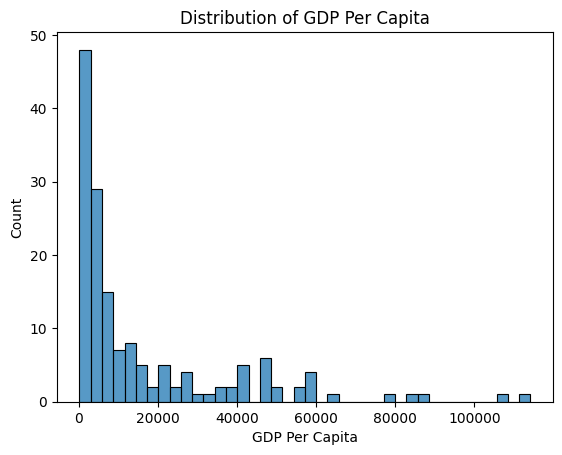

In [ ]:
hist0 = sns.histplot(x="GDP Per Capita", data=avrg_df, bins = 40) # This is just an histogram of GDP Per Capita using seaborn to see the distribution of the variable.
plt.title("Distribution of GDP Per Capita") # This is just to give it a title
# Note this is the same process for the other variables

 GDP per Capita is heavily right skewed, with most countries having a low GDP closer to zero (never actually zero), while a few rich countries have GDP Per Capita of over $60,000. For OLS however, this means that extremely rich countries will dominate the regression.

 I'll take logs of GDP Per Capita to penalise richer countries and bring them closer to scale, though the interpretation changes to percentage differences rather than absolute changes.

In [ ]:
avrg_df["logGDPc"] = np.log(avrg_df["GDP Per Capita"]) # This is to create a seperate column of the logarithm of GDP Per Capita. I use np.log to take the log of the entire column

Text(0.5, 1.0, 'Distribution of Log GDP Per Capita')

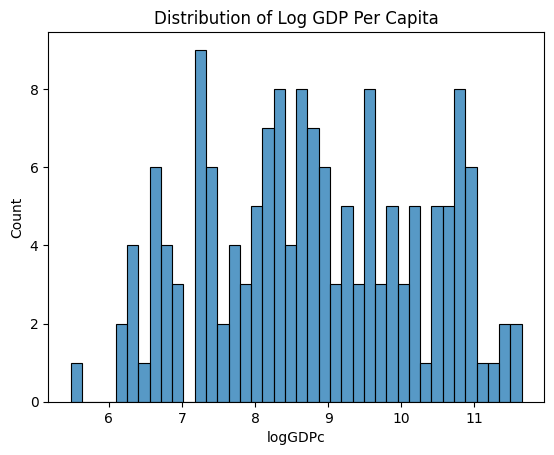

In [ ]:
hist1 = sns.histplot(x = "logGDPc", data = avrg_df, bins = 40) # This is to show the distribution of the new log GDP Per Capita variable
plt.title("Distribution of Log GDP Per Capita")

After taking the log of GDP Per Capita, the new distribution looks a lot more symmetrical.

Text(0.5, 1.0, 'Distribution of Natural Resources')

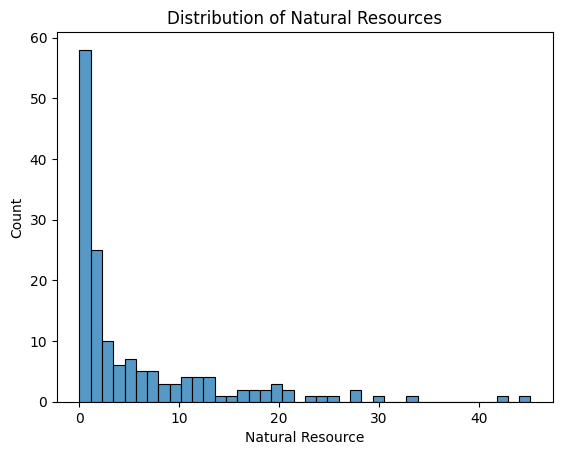

In [ ]:
hist2 = sns.histplot(x="Natural Resource", data=avrg_df, bins = 40)
plt.title("Distribution of Natural Resources")

Similarly to GDP Per Capita, the distribution of Natural Resources is heavily right skewed. However, unlike GDP Per Capita, which is a continuous variable, a lot of countries have zero Natural Resources making up a percentage of their GDP. Therefore, taking logs without having to manipulate the values of countries with 0 Natural Resource rents is not possible. (You cannot take logs of zero).

For now, I'll run the regression as is. However, I could create a dummy variable at a threshold to see the difference between countries with low and high natural resource rents.

Text(0.5, 1.0, 'Distribution of Agriculture')

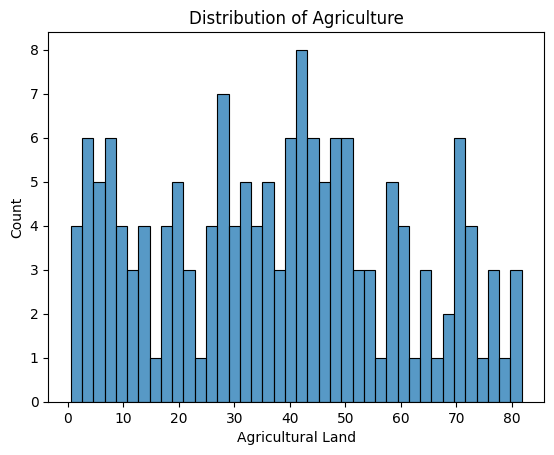

In [ ]:
hist3 = sns.histplot(x="Agricultural Land", data=avrg_df, bins = 40)
plt.title("Distribution of Agriculture")

The distribution of Agricultural Land is more evenly distributed. Since there are no signs of squewness its fine to leave the data as is.

- **`Scatterplots to visualise potential relationships`**

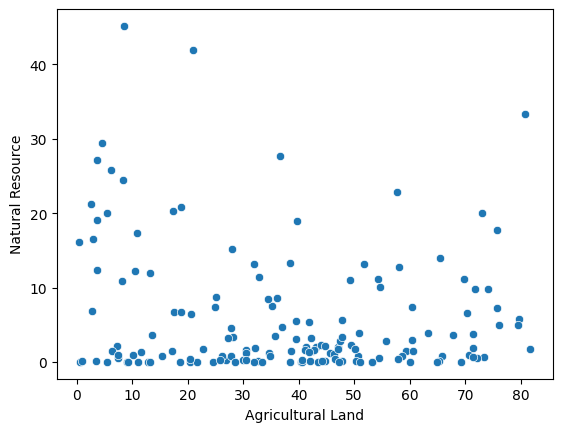

In [ ]:
plot0 = sns.scatterplot(x = "Agricultural Land" , y = "Natural Resource", data = avrg_df) # This is a scatterplot between my dependent variables. Mainly to visually diagnose potential multicoinearity

The scatterplot between Natural Resource rents and Agricultural Land looks randomly distributed with no meaningful relationship to note. However, you can see that a lot of countries have very low, if not zero, natural resource rents. Though, once again, the horizontal spread around zero suggests there isn't much of a relationship between countries with low natural resource rents and agricultural land. Multicollinearity shouldn't be an issue within these variables.

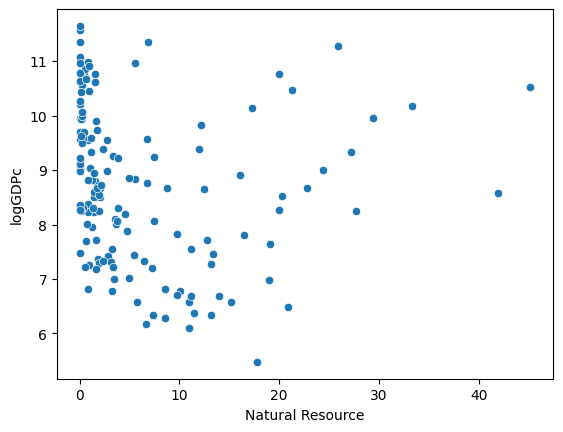

In [ ]:
plot3 = sns.scatterplot(x = "Natural Resource" , y = "logGDPc", data = avrg_df) # Scatterplot to see any poteantial relationship between Natural Resources and Log GDP Per Capita

The scatterplot of log GDP per capita shows that many high income countries have close to zero natural resource rents, suggesting that richer countries do not necessarily rely on natural resources as a major part of their GDP. Beyond low levels of resource dependence (above, let's say, 5%), there appears to be a weak positive relationship between the two variables, although the relationship is still ambiguous.

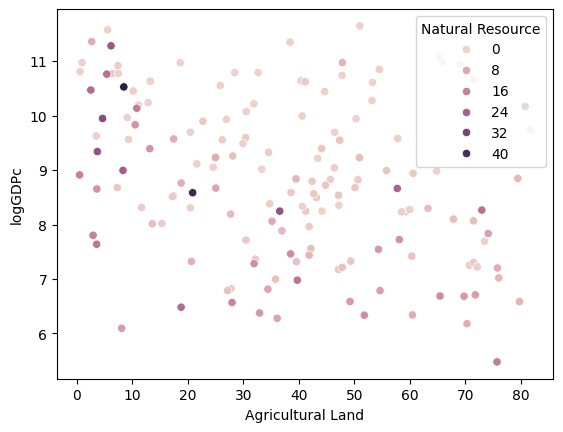

In [ ]:
plot2 = sns.scatterplot(x = "Agricultural Land" , y = "logGDPc", hue = "Natural Resource", data = avrg_df) # Scatterplot to see any poteantial relationship between Agriculture and log GDP Per Capita. I make Natural Resources my hue so i can visualise if Natural Resources is abundant amongst countries

Using the log of GDP Per Capita reveals a slightly weaker negative linear relationship. The relationship overall is still ambiguous without running a formal OLS regression. I also decided to colour code countries into groups according to the amount of resource rents they have. It shows that most countries have resource rents below 8% (% of GDP). A few countries are above a 16% threshold.

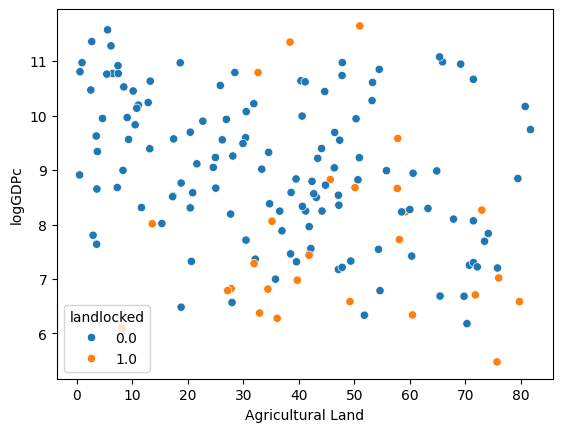

In [ ]:
plot1 = sns.scatterplot(x = "Agricultural Land" , y = "logGDPc", hue="landlocked", data = avrg_df) # Same scatterplot but i decidec to make the landlock status the hue instead.

This scatterplot is similar to the previous one, however for this I decided to highlight landlocked countries. It shows that while most countries are not landlocked, the highlighted points suggest that landlocked countries tend to be more concentrated at lower levels of GDP per capita, although there is still some overlap.

# **REGRESSIONS**

Simple Initial regressions to show across country variation

In [ ]:
x = avrg_df["Agricultural Land"] # Assigning agriculture as my X variable
y = avrg_df["logGDPc"] # Assigning logGDP per capita as my Y variable
x = sm.add_constant(x) # Assigning a constant. In this case is doesn't make sence to have 0 agricultural land or GDP Per Capita
model0 = sm.OLS(y,x).fit() # This is to fit my model and get results.
print(model0.summary()) # Using ".summary", I can now see the resuts I fitted earlier on. This is the same similar process for the next regressions

                            OLS Regression Results                            
Dep. Variable:                logGDPc   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                  0.101
Method:                 Least Squares   F-statistic:                     18.43
Date:                Thu, 14 May 2026   Prob (F-statistic):           3.10e-05
Time:                        12:44:12   Log-Likelihood:                -269.34
No. Observations:                 156   AIC:                             542.7
Df Residuals:                     154   BIC:                             548.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 9.6114      0.21

The regression result shows that a unit increase in agricultural land (% of total land area) is associated with approximately a -2.1% decrease in GDP Per Capita. At first glance, it suggests that more agriculture is associated with lower GDP Per Capita, however, perhaps high income countries don't rely on agriculture in the first place. Structurally, high income countries have more diversified economies beyond the primary sector. Low income countries may rely on agriculture, even if agriculture itself may not solely explain why they're poor. The relationship is likely not causal at this stage. It's likely a reflection of how economies structurally adapt.

In [ ]:
x = avrg_df[["Agricultural Land","Natural Resource"]] # Including Natural Resources to the model by incuding it to x.
y = avrg_df["logGDPc"]
x = sm.add_constant(x)
model1 = sm.OLS(y,x).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                logGDPc   R-squared:                       0.159
Model:                            OLS   Adj. R-squared:                  0.148
Method:                 Least Squares   F-statistic:                     14.48
Date:                Thu, 14 May 2026   Prob (F-statistic):           1.74e-06
Time:                        12:44:12   Log-Likelihood:                -264.63
No. Observations:                 156   AIC:                             535.3
Df Residuals:                     153   BIC:                             544.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 9.9438      0.23

Including natural resource rents in the model shows that a one-unit increase in resource rents (as a percentage of GDP) is associated with approximately a 3.95% decrease in GDP per capita. Similarly, agricultural land remains negatively associated with income, with a unit increase corresponding to around a 2.4% decrease in GDP per capita. The results are consistent with earlier findings and suggest a persistent negative correlation between resource dependence and income. However, once again, the relationships should not be interpreted causally.

They likely reflect structural differences in economic development, where high income countries tend to rely less on primary sectors such as agriculture and natural resource trade and instead operate mainly in the tertiary and quaternary sectors. This is further supported by the relatively low explanatory power of the model and suggests that omitted variable bias is likely present, with other factors such as institutions, human capital, and trade openness also playing roles in determining GDP per capita.

In [ ]:
x = avrg_df[["Agricultural Land","Natural Resource","landlocked"]] # Now I include "landlocked" to my explanotary variables.
y = avrg_df["logGDPc"]
x = sm.add_constant(x)
model2 = sm.OLS(y,x).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                logGDPc   R-squared:                       0.220
Model:                            OLS   Adj. R-squared:                  0.205
Method:                 Least Squares   F-statistic:                     14.33
Date:                Thu, 14 May 2026   Prob (F-statistic):           2.87e-08
Time:                        12:44:12   Log-Likelihood:                -258.73
No. Observations:                 156   AIC:                             525.5
Df Residuals:                     152   BIC:                             537.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 9.9430      0.23

In [ ]:
interpretation = ((np.exp(-0.9678)-1)*100) # This is just to convert the landlocked coefficient so its interpretable since I used logs of GDPpC - AI
print(interpretation)

-62.00820611587052


Now after including a dummy variable for landlocked countries, the result shows a coefficient of -0.9678. Then, converting for the correct interpretation, the result shows that being landlocked is associated with approximately 62% lower GDP per capita on average. The earlier scatterplot did indicate this, as most landlocked countries were on the lower end of GDP Per Capita. Agriculture and Resource rents remain negatively correlated with log GDP Per Capita. Perhaps landlocked countries without direct access to sea trade struggle to compete with most other countries.

However, there are still some other high income countries that are also landlocked. There are likely some other structural effects explaining the differences.

#**FIXED EFFECTS MODEL/REGRESSION**

A fixed effects model is used to measure the variation within the same countries over time, rather than across countries. This helps with removing some unobserved effects linked to structural differences like institutions, historical backgrounds, or culture. Variables that remain unchanged over time are dropped by the model. A random effects model is similar, but its assumptions and use cases make it unnecessary for me to use for this project.

In [ ]:
FE_df["logGDPpC"] = np.log(FE_df["GDP Per Capita"]) # Now Im switching to the Fixed effects model so im retaking logs of GDP Per Capita like i done earlier

Text(0.5, 1.0, 'Natural Resource Lineplot by country')

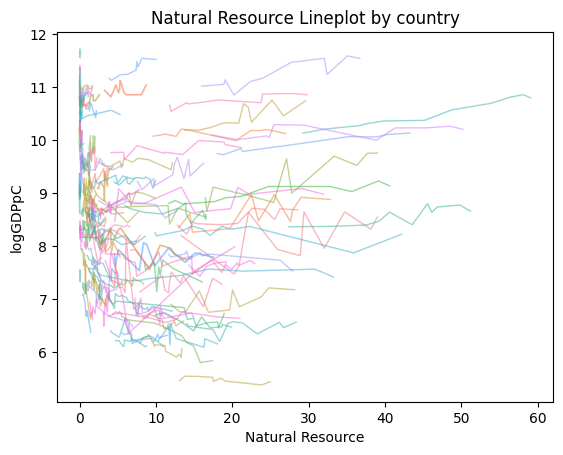

In [ ]:
FE_0 = sns.lineplot(x = "Natural Resource", y = "logGDPpC", hue = "Country Name", legend = False, alpha=0.5,linewidth=1, data = FE_df) # This is a lineplot to show how the same country variation exists for natural resources. Legend = 0 is to remove the country indicator which blocks the plot. Alpha is to make the lines more transparent so its easier to visualise.
plt.title("Natural Resource Lineplot by country")

Text(0.5, 1.0, 'Agriculture Scatterplot by country')

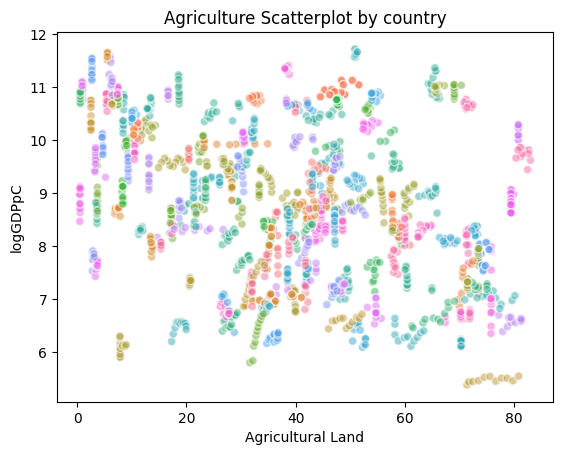

In [ ]:
FE_1 = sns.scatterplot(x = "Agricultural Land", y = "logGDPpC", hue = "Country Name", legend = False, alpha=0.5,linewidth=1, data = FE_df) # Same idea but with a scatterplot. This is to show agricultural land barely changes with time
plt.title("Agriculture Scatterplot by country")

The lineplot shows countries in different colours clearly have their own trends. It further suggests that countries likely have their own specific effects that a standard regression cannot capture. These are likely some of the structural effects I mentioned earlier aside from omitted variable bias. It pushes me towards running a fixed effects model, assuming the unobserved effects are likely correlated to GDP Per Capita.

On the other hand, Agricultural Land doesn't seem to have much within variation, which makes sense. Structural effects are likely more omitted variable bias than unobserved effects. Similarly, a country being landlocked or not doesn't change, so it's meaningless in a fixed effects model.

In [ ]:
FE_df.head() # Just to re check how the dataframe looks.

,Country Name,Country Code,Year,Natural Resource,Agricultural Land,GDP Per Capita,landlocked,logGDPpC
0,Albania,ALB,2010,1.528168,43.843066,4149.144699,0,8.330657
1,Algeria,DZA,2010,25.538324,17.371334,4912.785855,0,8.499596
2,Andorra,AND,2010,0.000000,42.063830,42746.830392,0,10.663050
3,Angola,AGO,2010,38.162310,35.974974,4101.637156,0,8.319141
4,Antigua and Barbuda,ATG,2010,0.000000,20.454545,15217.395079,0,9.630194


In [ ]:
FE_df["Year"] = FE_df["Year"].astype(int) # Converted my year column to integers which is required for panel regression

In [ ]:
FE_df = FE_df.set_index(["Country Name","Year"]) # This is to set the groups as the indexes so Python can categorise which is needed for Panel Regression

In [ ]:
FE_df.head()

,,Country Code,Natural Resource,Agricultural Land,GDP Per Capita,landlocked,logGDPpC
Country Name,Year,,,,,,
Albania,2010,ALB,1.528168,43.843066,4149.144699,0,8.330657
Algeria,2010,DZA,25.538324,17.371334,4912.785855,0,8.499596
Andorra,2010,AND,0.000000,42.063830,42746.830392,0,10.663050
Angola,2010,AGO,38.162310,35.974974,4101.637156,0,8.319141
Antigua and Barbuda,2010,ATG,0.000000,20.454545,15217.395079,0,9.630194


In [ ]:
x = FE_df[["Natural Resource","Agricultural Land"]] # Setting my x variables
y = FE_df["logGDPpC"]
x = sm.add_constant(x)
fe_model = PanelOLS(y,x, entity_effects=True, time_effects=True).fit() # Fitting the panel model - entity effects tells python to regress based on the groups specifically Countries and Time effects helps with adjusting for global shocks that impact all countries during specific periods, so it doesn't wrongly include it as part of the effects
print(fe_model.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:               logGDPpC   R-squared:                        0.0470
Estimator:                   PanelOLS   R-squared (Between):             -0.0902
No. Observations:                1804   R-squared (Within):               0.0215
Date:                Thu, May 14 2026   R-squared (Overall):             -0.0881
Time:                        12:44:23   Log-likelihood                    1045.2
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      40.307
Entities:                         156   P-value                           0.0000
Avg Obs:                       11.564   Distribution:                  F(2,1636)
Min Obs:                       11.000                                           
Max Obs:                       22.000   F-statistic (robust):             40.307
                            

TThe fixed effects model now shows a one unit increase in Natural Resources to be associated with approximately a 1.03% change in log GDP per capita on average. The change in sign from -0.0337 to +0.0103 indicates that within countries, greater natural resource rents can be associated with greater GDP once time invariant structural differences are accounted for.

The negative relation previously found in the standard OLS models likely captured between-country variation where richer countries have less reliance on natural resources, hence resulting in a negative relationship which perhaps didn't tell the full story.

Additionally, Agricultural Land is now positively associated with a 0.59% increase in log GDP per Capita for each additional unit. Therefore, even with agriculture, you see a similar effect to resource rents, the negative relationship is between countries.

However, the within R-squared value of 0.0215, meaning the model only explains about 2.15% of the variation in GDP per capita within countries, indicates that the model has limited explanatory power based on the current number of regressors. It suggests including more control variables to fully capture GDP Per Capita variation.

# **ADDITIONAL CONTROL VARIABLES**

`Education` `Electricity` `Investment`

I decided to include education, electricity, and investment as my control variables.

- High investment countries are likely to also have higher GDP per capita, so it helps explain some of the variation in GDP per capita across countries. It captures differences in physical capital accumulation, which is a driver of economic output.

- Employment to population ratio is used as a proxy for labour in the economy. Countries with higher employment to population ratios are likely to have a larger share of the working age population engaged in productive activity, which leads to higher output per capita and therefore higher GDP per capita.

- Electricity is used as a proxy for infrastructure. Countries with higher electricity consumption tend to have higher productivity and more industrial activity. Wealthier countries also generally have higher demand for electricity, so it is likely linked to higher GDP per capita.

In [ ]:
inv_df = pd.read_csv("https://raw.githubusercontent.com/brysagay/Datascience_project/refs/heads/main/Investment.csv") # All my additional Control variables are from the World Bank API
elec_df = pd.read_csv("https://raw.githubusercontent.com/brysagay/Datascience_project/refs/heads/main/Electricity.csv")
empl_df = pd.read_csv("https://raw.githubusercontent.com/brysagay/Datascience_project/refs/heads/main/employment.csv")

In [ ]:
def cleanI(x): # Same cleaning process for my additional variables.
  x = x.replace(["..", "", " ", "NA", "N/A"], np.nan)
  x = x.dropna()
  x.columns = x.columns.str.replace(r" \[YR\d+\]", "", regex=True)
  x = x.drop(columns=["Series Name","Series Code"])
  x = x.melt(id_vars=["Country Name","Country Code"],var_name="Year",value_name="Investment")
  return x

In [ ]:
def cleanE(x):
  x = x.replace(["..", "", " ", "NA", "N/A"], np.nan)
  x = x.dropna()
  x.columns = x.columns.str.replace(r" \[YR\d+\]", "", regex=True)
  x = x.drop(columns=["Series Name","Series Code"])
  x = x.melt(id_vars=["Country Name","Country Code"],var_name="Year",value_name="Electricity")
  return x

In [ ]:
def cleanEL(x):
  x = x.replace(["..", "", " ", "NA", "N/A"], np.nan)
  x = x.dropna()
  x.columns = x.columns.str.replace(r" \[YR\d+\]", "", regex=True)
  x = x.drop(columns=["Series Name","Series Code"])
  x = x.melt(id_vars=["Country Name","Country Code"],var_name="Year",value_name="Employment_R")
  return x

In [ ]:
inv_df = cleanI(inv_df)
elec_df = cleanE(elec_df)
empl_df = cleanEL(empl_df)

In [ ]:
inv_df.head(3)

,Country Name,Country Code,Year,Investment
0,Albania,ALB,2010,3.220106e+09
1,Algeria,DZA,2010,6.949249e+10
2,Angola,AGO,2010,2.523675e+10


In [ ]:
elec_df.head(3)

,Country Name,Country Code,Year,Electricity
0,Albania,ALB,2010,1943.343354
1,Algeria,DZA,2010,1010.715195
2,Angola,AGO,2010,206.998765


In [ ]:
empl_df.head(3)

,Country Name,Country Code,Year,Employment_R
0,Afghanistan,AFG,2010,43.159
1,Albania,ALB,2010,47.426
2,Algeria,DZA,2010,39.174


In [ ]:
econ0 = pd.merge(empl_df,elec_df, on = ["Year","Country Code","Country Name"])

In [ ]:
econ0 = pd.merge(econ0,inv_df, on = ["Year","Country Code","Country Name"])

In [ ]:
econ0.head(3)

,Country Name,Country Code,Year,Employment_R,Electricity,Investment
0,Albania,ALB,2010,47.426,1943.343354,3.220106e+09
1,Algeria,DZA,2010,39.174,1010.715195,6.949249e+10
2,Angola,AGO,2010,64.438,206.998765,2.523675e+10


In [ ]:
econ0["Year"] = econ0["Year"].astype(int)

In [ ]:
FE_df = FE_df.reset_index()

In [ ]:
FE_df = pd.merge(FE_df,econ0, on = ["Year","Country Code","Country Name"])

In [ ]:
FE_df.head(3)

,Country Name,Year,Country Code,Natural Resource,Agricultural Land,GDP Per Capita,landlocked,logGDPpC,Employment_R,Electricity,Investment
0,Albania,2010,ALB,1.528168,43.843066,4149.144699,0,8.330657,47.426,1943.343354,3.220106e+09
1,Algeria,2010,DZA,25.538324,17.371334,4912.785855,0,8.499596,39.174,1010.715195,6.949249e+10
2,Angola,2010,AGO,38.162310,35.974974,4101.637156,0,8.319141,64.438,206.998765,2.523675e+10


`Distribution for control variables`

Text(0.5, 1.0, 'Distribution of Electricity')

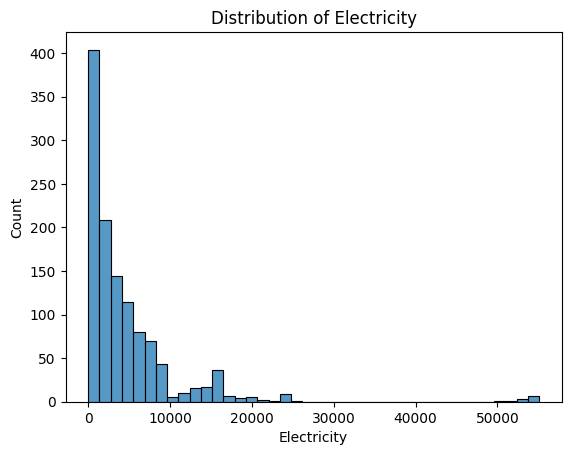

In [ ]:
hist4 = sns.histplot(x = "Electricity", data = FE_df, bins = 40 ) # Same check for distribution as previous variables
plt.title("Distribution of Electricity")

Text(0.5, 1.0, 'Distribution of Investment')

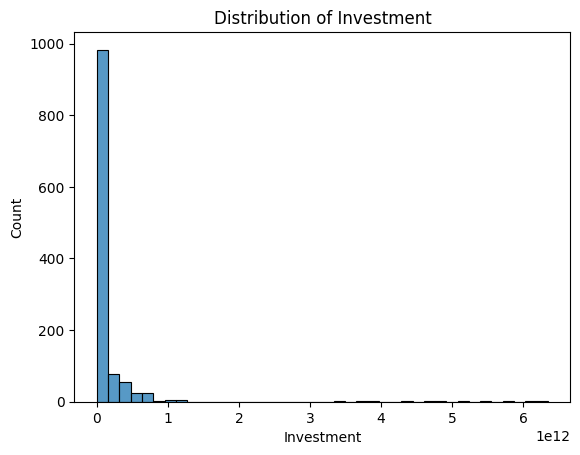

In [ ]:
hist6 = sns.histplot(x = "Investment", data = FE_df, bins = 40)
plt.title("Distribution of Investment")

Both investment and electricity are heavily right skewed, similar to GDP per capita. Taking the logarithm of the variables helps reduce skewness and brings countries with very high values closer to a comparable scale, making the relationships easier to interpret.

In [ ]:
FE_df["logInvestment"] = np.log(FE_df["Investment"])
FE_df["logElectricity"] = np.log(FE_df["Electricity"])

Text(0.5, 1.0, 'Distribution of Log Electricity')

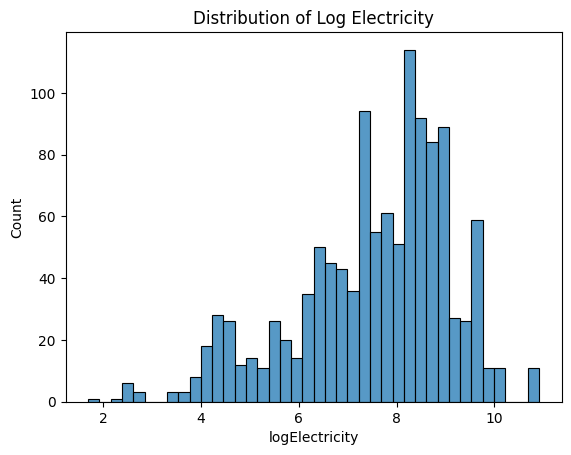

In [ ]:
hist5 = sns.histplot(x = "logElectricity", data = FE_df, bins = 40)
plt.title("Distribution of Log Electricity")



Text(0.5, 1.0, 'Distribution of Log Investment')

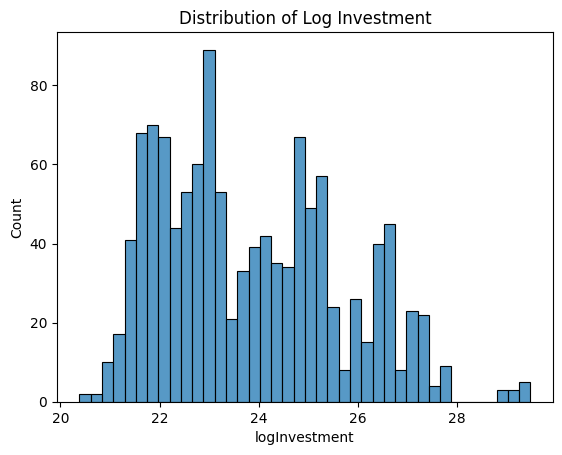

In [ ]:
hist6 = sns.histplot(x = "logInvestment", data = FE_df, bins = 40)
plt.title("Distribution of Log Investment")


Once the logarithm of both variables is taken, the skewness reduces. Though both variables are still somewhat skewed, it's not as extreme as the previous distributions.

Text(0.5, 1.0, 'Distribution of Employment Rate')

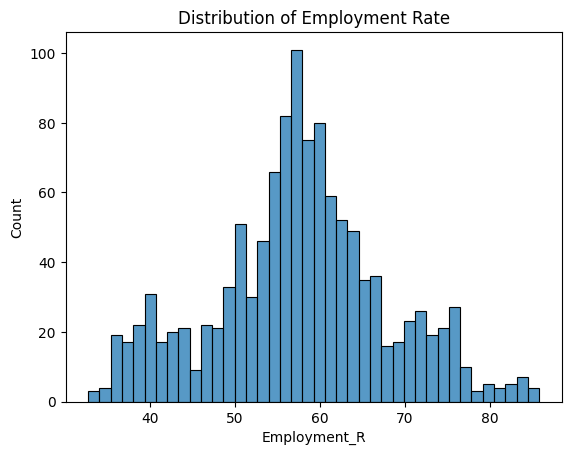

In [ ]:
hist7 = sns.histplot(x = "Employment_R", data = FE_df, bins = 40 )
plt.title("Distribution of Employment Rate")

Employment appears relatively normally distributed, with most countries falling between a 50-70% employment to population ratio. Therefore, there is no need to further transform the variable.

# **FINAL MODELS**

**FIXED EFFECTS MODEL/REGRESSION + CONTROL VARIABLES**








In [ ]:
FE_df = FE_df.set_index(["Country Name","Year"])

In [ ]:
x = FE_df[["Natural Resource","Agricultural Land","logElectricity","logInvestment","Employment_R"]] # Final x variables including all my control variables
y = FE_df["logGDPpC"]
x = sm.add_constant(x)
fe_model1 = PanelOLS(y,x, entity_effects=True, time_effects=True).fit()
print(fe_model1.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:               logGDPpC   R-squared:                        0.3771
Estimator:                   PanelOLS   R-squared (Between):              0.6178
No. Observations:                1188   R-squared (Within):               0.4096
Date:                Thu, May 14 2026   R-squared (Overall):              0.6308
Time:                        12:44:25   Log-likelihood                    966.87
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      129.66
Entities:                         102   P-value                           0.0000
Avg Obs:                       11.647   Distribution:                  F(5,1071)
Min Obs:                       11.000                                           
Max Obs:                       22.000   F-statistic (robust):             129.66
                            

With the additional control variables, Agriculture has once again gone back to being negatively correlated even within countries. Now a 1 unit increase in Agriculture is associated with a 0.6% decrease in GDP per Capita. Natural Resources remains fairly similar, with a 1.27% increase in GDP Per Capita for every unit increase in Natural Resources. Hence, unlike agriculture, natural resources shows a consistent positive association with GDP per Capita within countries, suggesting resources are a good component to have for higher GDP per capita in some countries.

However, it is important to note that the coefficients on the control variables are not directly comparable to those of the geographic variables due to differences in scaling. For example, a 1% increase in electricity use is associated with a 0.327% increase in GDP per capita. Similarly, a 1% increase in investment is associated with approximately a 0.337% increase in GDP per capita. This suggests that both geographic and economic factors play important roles, although their impacts operate differently in this model.

**POOLED REGRESSION + CONTROL VARIABLES**


In [ ]:
x = FE_df[["Natural Resource","Agricultural Land","logElectricity","logInvestment","Employment_R","landlocked"]]
y = FE_df["logGDPpC"]
x = sm.add_constant(x)
pooled_model = PooledOLS(y,x,).fit()
print(pooled_model.summary)

                          PooledOLS Estimation Summary                          
Dep. Variable:               logGDPpC   R-squared:                        0.8127
Estimator:                  PooledOLS   R-squared (Between):              0.8153
No. Observations:                1188   R-squared (Within):               0.0860
Date:                Thu, May 14 2026   R-squared (Overall):              0.8127
Time:                        12:44:25   Log-likelihood                   -1089.3
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      854.29
Entities:                         102   P-value                           0.0000
Avg Obs:                       11.647   Distribution:                  F(6,1181)
Min Obs:                       11.000                                           
Max Obs:                       22.000   F-statistic (robust):             854.29
                            

Now in addition to Agriculture, Natural Resources is also negatively associated with GDP Per Capita at -0.0004. Though the p-value of the coefficient is larger than 0.05, at 0.8438, and hence insignificant. Across countries, the data suggests that not only does agriculture show a negative correlation with GDP Per Capita, it also cannot support any evidence of a relationship between Natural Resources and GDP Per Capita.

Additionally, the data now suggests that being landlocked is associated with a 13.96% increase in GDP Per Capita. However, this does not support the earlier graph that shows a larger concentration of non-landlocked countries at higher levels of GDP Per Capita. This suggests that the positive coefficient may not reflect a genuine causal relationship, but instead differences between countries within the sample. For example, some high-income European countries are landlocked, which may push the pooled estimate upwards.

In addition, landlocked status is a fixed geographic characteristic and may capture other country specific factors, such as institutional quality or regional development, instead of the actual economic impact of lacking sea access. Therefore, the coefficient does not provide reliable evidence that being landlocked increases GDP Per Capita.

Overall, I believe the regression does not provide enough evidence of a meaningful economic impact across countries through geographical factors. There are other economic variables that have a stronger impact on GDP Per Capita, suggesting that geographical advantages are not necessarily required for countries to achieve high levels of GDP Per Capita.

# **COMPARING RESULTS**

For comparing results, I decided to standardise my results for both my final models. The idea is to see the effects of a 1 standard deviation change of each variable on GDP Per Capita. The output is a visual representation of this change

`Fixed effects`

In [ ]:
FE_df_std = FE_df[["logGDPpC","Natural Resource","Agricultural Land","logElectricity","logInvestment","Employment_R"]].std() # Creating a dataframe of the standard deviations of each variable

In [ ]:
FE_df_std = FE_df_std.reset_index() # reseting the index so its easier to merge later on


In [ ]:
FE_df_std = FE_df_std.rename(columns={"index":"variables",0:"Standard Deviation"}) # Renaming the columsn for merging


In [ ]:
FE_df_std.head() # Checking the dataframe


,variables,Standard Deviation
0,logGDPpC,1.399427
1,Natural Resource,9.341588
2,Agricultural Land,20.732977
3,logElectricity,1.585509
4,logInvestment,1.818945


In [ ]:
params = fe_model1.params # Same Process

In [ ]:
params = params.reset_index()


In [ ]:
params = params.rename(columns={"index":"variables"})

In [ ]:
params.head()

,variables,parameter
0,const,-1.841846
1,Natural Resource,0.012681
2,Agricultural Land,-0.006012
3,logElectricity,0.327340
4,logInvestment,0.336596


In [ ]:
bar_df = pd.merge(params,FE_df_std, on = "variables") # Merging both dataframes

In [ ]:
bar_df

,variables,parameter,Standard Deviation
0,Natural Resource,0.012681,9.341588
1,Agricultural Land,-0.006012,20.732977
2,logElectricity,0.327340,1.585509
3,logInvestment,0.336596,1.818945
4,Employment_R,0.008558,10.326403


In [ ]:
bar_df["SD change"] = (bar_df["Standard Deviation"]/1.399427)*bar_df["parameter"] # Calculating the relative impacts on GDP Per Capita from each variable through standardisaiton. It takes each variable standard deviation, divides it by the standard deviaiton of log gdp per capita and multiplies it by the variable coefficient - AI

In [ ]:
bar_df

,variables,parameter,Standard Deviation,SD change
0,Natural Resource,0.012681,9.341588,0.084646
1,Agricultural Land,-0.006012,20.732977,-0.089073
2,logElectricity,0.327340,1.585509,0.370867
3,logInvestment,0.336596,1.818945,0.437500
4,Employment_R,0.008558,10.326403,0.063150


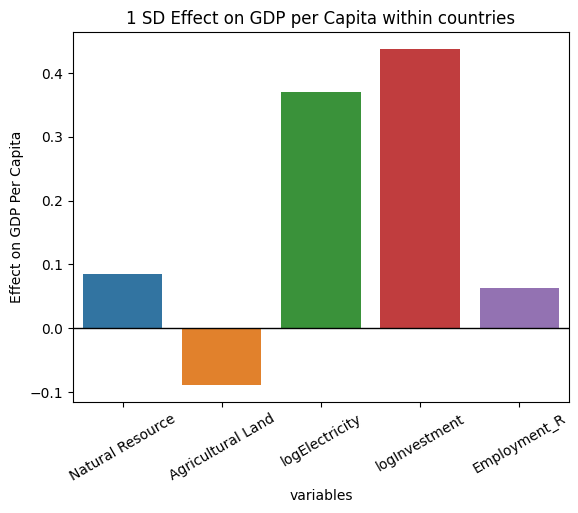

In [ ]:
f_barplot = sns.barplot(x="variables", y="SD change", data = bar_df, hue="variables") # Bar plot to show relative effects of 1 standard deviation change. Use hue so each variable has its own colour
plt.axhline(0, color="black", linewidth=1) # This just creates a horizontal line at 0
plt.xticks(rotation=30) # This is to rotate the variable names on the x axis by 30 degrees so they dont overlap
plt.title("1 SD Effect on GDP per Capita within countries") # title of the plot
plt.ylabel("Effect on GDP Per Capita")
plt.show() # To show all the previous changes made on the graph

For panel effects, the barplot shows that within countries Electricity use and Investment have the highest effect on GDP Per Capita with a single standard deviation change. This is then followed by Natural Resources and Employment rate. It shows that within countries, although Natural Resources have a positive effect on wealth per person, other economic variables matter even more. Agriculture is the only variable that is negative. It likely doesn't mean agriculture makes a country poor, but rather that countries which rely on agriculture are perhaps already poorer in the first place.

`Pooled effects`

In [ ]:
p_params = pooled_model.params # The whole process is the same - including the barplot.

In [ ]:
p_params = p_params.reset_index()

In [ ]:
p_params = p_params.rename(columns={"index":"variables"})

In [ ]:
p_params.head()

,variables,parameter
0,const,1.174743
1,Natural Resource,-0.000389
2,Agricultural Land,-0.003702
3,logElectricity,0.740019
4,logInvestment,0.085963


In [ ]:
bar_df_p = pd.merge(p_params,FE_df_std, on = "variables")

In [ ]:
bar_df_p["SD change"] = (bar_df_p["Standard Deviation"]/1.399427)*bar_df_p["parameter"]

In [ ]:
bar_df_p

,variables,parameter,Standard Deviation,SD change
0,Natural Resource,-0.000389,9.341588,-0.002594
1,Agricultural Land,-0.003702,20.732977,-0.054851
2,logElectricity,0.740019,1.585509,0.838420
3,logInvestment,0.085963,1.818945,0.111733
4,Employment_R,0.005220,10.326403,0.038520


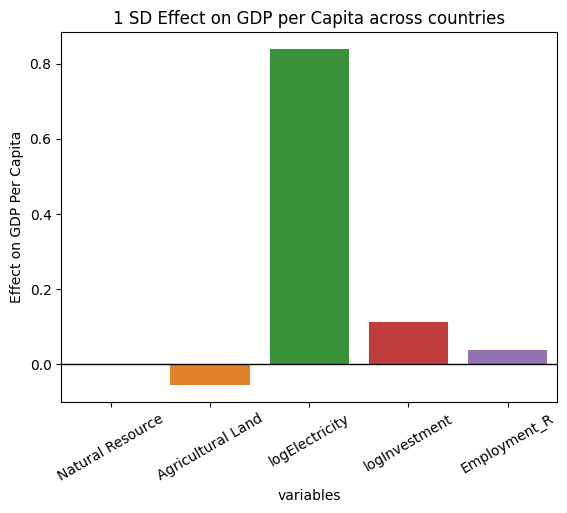

In [ ]:
p_barplot = sns.barplot(x="variables", y="SD change", data = bar_df_p, hue="variables")
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=30)
plt.ylabel("Effect on GDP Per Capita")
plt.title("1 SD Effect on GDP per Capita across countries")
plt.show()

Now across countries, the effect of electricity use is even more associated with GDP Per Capita. Infrastructure is perhaps a big indicator for economic wealth across countries as it is needed for generating economic output in the first place. For example, factories and businesses require electricity. Investment and Employment have remained positive. Though now, Resources shows a negligible effect on wealth per person. Between countries, Natural Resources are not required for wealth creation. They are helpful but not required. Agricultural Land has remained negative, further reinforcing the idea that agricultural land is a sector most developed and therefore richer economies move away from during growth. It's important to note however that not all factors have been accounted for, so additional variables may change results if included.

# **MODEL DIAGNOSTICS**

This model diagnostics section is aimed at making sure the linear model is appropriate for the data. By plotting the residuals against fitted values, any patterns that might show relationships or potential heteroskedasticity can be visualised and hence fixed or mentioned as limitations.

**Fixed effects**

In [ ]:
fe_resids = fe_model1.resids.reset_index() # Assigning the model residuals and reseting the index so i can merge later on

In [ ]:
fe_fittedmodels = fe_model1.fitted_values.reset_index() # Same as previous but with the fitted values


In [ ]:
fe_fittedmodels.head(3) # Checking the dataframe for each new dataset

,Country Name,Year,fitted_values
0,Albania,2010,8.167465
1,Algeria,2010,9.380415
2,Angola,2010,8.784847


In [ ]:
fe_resids.head(3)

,Country Name,Year,residual
0,Albania,2010,-0.018906
1,Algeria,2010,0.123328
2,Angola,2010,0.183646


In [ ]:
fe_diagnostics = pd.merge(fe_resids,fe_fittedmodels, on = (["Year","Country Name"])) # Merging both datasets

In [ ]:
fe_diagnostics.head(3)

,Country Name,Year,residual,fitted_values
0,Albania,2010,-0.018906,8.167465
1,Algeria,2010,0.123328,9.380415
2,Angola,2010,0.183646,8.784847


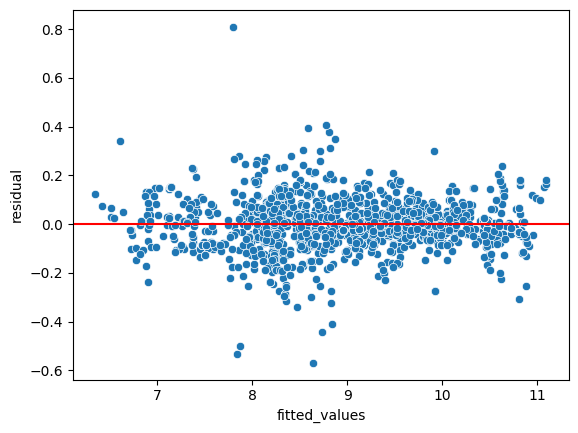

In [ ]:
fe_m1resid = sns.scatterplot(x = "fitted_values" , y = "residual", data = fe_diagnostics) # This is a scatterplot showing the distribution of residuals against predicted values
plt.axhline(y = 0,color="red") # A red horizontal line at 0 to see how the points are scattered around the value.

Overall, the residuals appear to be randomly distributed around the zero line, suggesting that the model does not suffer from any major systematic bias. Most observations are concentrated close to zero, indicating that the model predicts GDP Per Capita reasonably well for the majority of countries in the sample.

However, there are still some outliers and a slightly wider spread of residuals at certain fitted values, which may suggest some heteroskedasticity. However, there is no strong visible pattern or trend in the residuals, suggesting that the linear specification of the model is generally appropriate.

**Pooled**

In [ ]:
p_resids = pooled_model.resids.reset_index() # The same process as with the Fixed residuals

In [ ]:
p_fittedmodels = pooled_model.fitted_values.reset_index()

In [ ]:
pool_diagnostics = pd.merge(p_resids,p_fittedmodels , on = (["Year","Country Name"]))

In [ ]:
pool_diagnostics.head(3)

,Country Name,Year,residual,fitted_values
0,Albania,2010,-0.414249,8.744907
1,Algeria,2010,-0.071182,8.570779
2,Angola,2010,0.950784,7.368357


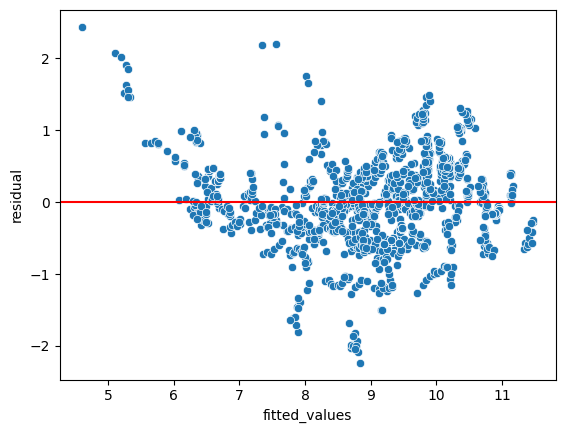

In [ ]:
pool_resid = sns.scatterplot(x = "fitted_values" , y = "residual", data = pool_diagnostics)
plt.axhline(y = 0,color="red")

For the pooled regression, the residuals seem to be fairly randomly distributed around zero, which suggests there is no systemic bias in the model. There also do not appear to be any clear patterns, which suggests that using a linear specification is appropriate. However, at lower fitted values there are a few outliers where the model overpredicts. In addition to that, around fitted values of 8, the model tends to both overpredict and underpredict more frequently, suggesting some increase in variance at certain levels of fitted GDP per capita. It suggests some possible heteroskedasticity.

 However, overall the residuals still appear reasonably randomly distributed without any strong or consistent pattern, so the linear model remains a reasonable specification.

---



# **Limitations**

1. **One limitation of this project is that the analysis cannot fully establish causality between geographic factors and GDP per capita. Although the regressions identify correlations between variables such as agricultural land, natural resources, and landlocked status, economic performance is influenced by a much wider range of structural factors. Variables such as trade openness, technological progress, healthcare, and historical development are difficult to fully capture within the models and may still create omitted variable bias.**
- As an improvement, I could've included some more institutional or societal control variables, such as institutional quality, political stability, or even corruption, particularly in the pooled regressions.

2. **Another limitation is that some of the geographic variables themselves may not perfectly measure the concepts they intend to capture. For example, agricultural land as a percentage of total land area does not measure the productivity or quality of the land. Similarly, natural resource rents only measure the share of GDP generated from resources rather than the total quantity or long term sustainability of those resources**.
- If I had more time, I'd try to find a way of including a measure for land quality as a variable. I tried to include some proxies for productivity, but I found most variables measured broader productivity and available datasets contained too many missing values.

3. **There are also limitations relating to the data structure. While the fixed effects model helps account for unobserved country specific effects, several geographic variables such as landlocked status are time invariant and therefore cannot be meaningfully estimated within the fixed effects framework. In addition, some variables showed very little within-country variation over time, making it harder to identify strong within effects.**
- With more time, I'd switch landlocked status with another geographic variable. For example, I could use climate, which could work well alongside agriculture since they link to each other.

4. **Finally, there may still be issues relating to heteroskedasticity and outliers within the data. Although the residual plots did not reveal any major systematic patterns, some fitted values displayed wider spreads in residuals, suggesting that the variance of the errors may not be completely constant across observations.**



# **Conclusion**

Overall, the project finds that geographic factors do appear to have some relationship with GDP per capita, although the direction and strength of the relationships depend heavily on the modelling approach used.

The pooled OLS regressions generally suggested that countries with larger agricultural sectors and higher natural resource dependence tend to have lower GDP per capita. However, the relationships likely reflected structural differences between countries rather than causal effects. Many high income countries rely less on primary sectors and instead generate output mainly through services, technology, and advanced industries.

Once fixed effects were introduced, the relationships changed noticeably. Natural resource rents became positively associated with GDP per capita within countries, suggesting that increases in resource rents may contribute positively to economic performance after accounting for time invariant structural differences. The effect of agricultural land was less consistent, switching sign depending on the inclusion of additional control variables.

The analysis therefore suggests that geography alone cannot determine economic success. Geographic advantages such as natural resources may provide economic opportunities, but other structural factors such as infrastructure, investment, education, and institutional development likely play a much larger role in determining long run income differences across countries.

Finally, the findings support the idea that geography matters, but only as one component within a much broader economic system.